

### Dataset
Usaremos el conjunto de datos de **House Prices** de **Kaggle**, que tiene tanto características numéricas como categóricas. A continuación te muestro cómo implementar la solución.

### Paso 1: Cargar y preprocesar el conjunto de datos


In [1]:
# Instalar Optuna
!pip install optuna # Aquí no lo usaremos, pero quedas invitado a usarlo!

# Instalar CatBoost
!pip install catboost

# Instalar LightGBM
!pip install lightgbm

# Instalar XGBoost
!pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.8/362.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.2/233.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Cargar el dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

# Dividir las características (X) y el target (y)
X = df.drop(columns='medv')  # 'medv' es la variable objetivo (precio de las casas)
y = df['medv']

# Identificar columnas categóricas y numéricas
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB



### Paso 2: Preprocesamiento

- Para **XGBoost** y **LightGBM**, necesitamos codificar las características categóricas.
- Para **CatBoost**, no es necesario preprocesar las características categóricas.


In [3]:
# Preprocesamiento de variables categóricas y numéricas para XGBoost y LightGBM
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])


### Paso 3: Definir los modelos

Vamos a definir los modelos de **CatBoost**, **XGBoost** y **LightGBM** para usarlos en los pipelines.


In [4]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Modelos de regresión
xgb_model = XGBRegressor(random_state=42)
lgbm_model = LGBMRegressor(random_state=42)
cat_model = CatBoostRegressor(silent=True, random_state=42)

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)



### Paso 4: Definir los espacios de hiperparámetros para RandomizedSearchCV


In [5]:
# Espacios de búsqueda de hiperparámetros
xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
}

lgbm_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__num_leaves': [31, 50, 100],
}

cat_param_grid = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 10],
}


### Paso 5: Definir los pipelines

- Para **XGBoost** y **LightGBM**, incluimos el preprocesador.
- Para **CatBoost**, pasamos las columnas categóricas directamente al modelo sin preprocesarlas.


In [6]:
# Pipelines para los modelos

# Pipeline para XGBoost y LightGBM
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb_model)])
lgbm_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', lgbm_model)])

# Pipeline para CatBoost (sin preprocesamiento de variables categóricas)
cat_pipeline = cat_model


### Paso 6: Nested Cross-Validation con RandomizedSearchCV


In [7]:
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score

# Crear folds para validación cruzada
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

# RandomizedSearchCV para cada modelo

# XGBoost
xgb_random_search = RandomizedSearchCV(estimator=xgb_pipeline,
                                       param_distributions=xgb_param_grid,
                                       cv=inner_cv, n_iter=10, scoring='neg_mean_squared_error', random_state=42)

# LightGBM
lgbm_random_search = RandomizedSearchCV(estimator=lgbm_pipeline,
                                        param_distributions=lgbm_param_grid,
                                        cv=inner_cv, n_iter=10, scoring='neg_mean_squared_error', random_state=42)

# CatBoost (sin pipeline)
cat_random_search = RandomizedSearchCV(estimator=cat_pipeline,
                                       param_distributions=cat_param_grid,
                                       cv=inner_cv, n_iter=10, scoring='neg_mean_squared_error', random_state=42)



In [8]:

# Nested Cross-validation para elegir el mejor modelo
xgb_nested_scores = cross_val_score(xgb_random_search, X_train, y_train, cv=outer_cv, scoring='neg_mean_squared_error')
lgbm_nested_scores = cross_val_score(lgbm_random_search, X_train, y_train, cv=outer_cv, scoring='neg_mean_squared_error')
cat_nested_scores = cross_val_score(cat_random_search, X_train, y_train, cv=outer_cv, scoring='neg_mean_squared_error')

# Imprimir resultados
print(f"XGBoost Nested CV MSE: {-np.mean(xgb_nested_scores)}")
print(f"LightGBM Nested CV MSE: {-np.mean(lgbm_nested_scores)}")
print(f"CatBoost Nested CV MSE: {-np.mean(cat_nested_scores)}")

Se truncaron las últimas líneas 5000 del resultado de transmisión.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s


### Paso 7: Curvas de aprendizaje

Podemos mostrar las curvas de aprendizaje para cada modelo durante el ajuste. Te muestro cómo hacerlo para **XGBoost**, **LightGBM** y **CatBoost**:


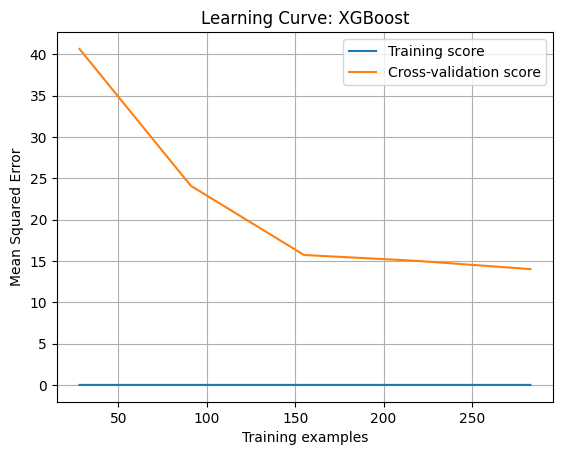

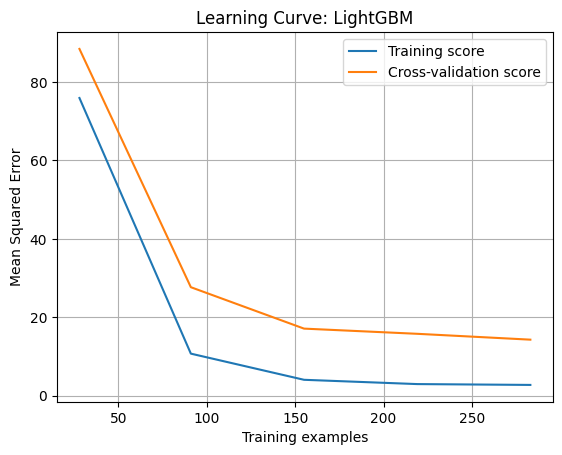

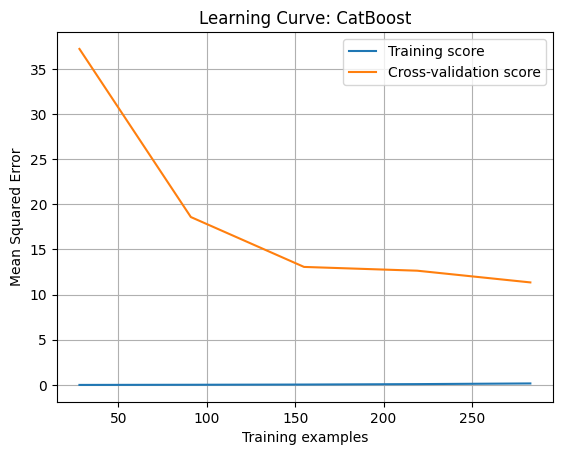

In [9]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=None, n_jobs=-1):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, scoring='neg_mean_squared_error')
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)

    plt.figure()
    plt.title(title)
    plt.plot(train_sizes, train_scores_mean, label="Training score")
    plt.plot(train_sizes, test_scores_mean, label="Cross-validation score")
    plt.xlabel("Training examples")
    plt.ylabel("Mean Squared Error")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Generar curvas de aprendizaje para cada modelo
plot_learning_curve(xgb_pipeline, "Learning Curve: XGBoost", X_train, y_train, cv=outer_cv)
plot_learning_curve(lgbm_pipeline, "Learning Curve: LightGBM", X_train, y_train, cv=outer_cv)
plot_learning_curve(cat_pipeline, "Learning Curve: CatBoost", X_train, y_train, cv=outer_cv)


Este ejemplo muestra cómo:
- Utilizamos **CatBoost** sin necesidad de preprocesar las variables categóricas.
- Realizamos **validación cruzada anidada (nested cross-validation)** con **Randomized Grid Search** para comparar los modelos.
- Graficamos las **curvas de aprendizaje** para ver el rendimiento a lo largo del entrenamiento.


Para mostrar las **mejores características** de cada modelo, se pueden usar diferentes métricas de importancia de características dependiendo del modelo. A continuación, se incluirán códigos que no solo se basan en el **gain** para mostrar la importancia de características.

### Estrategia para mostrar la importancia de características por modelo:
1. **XGBoost** y **LightGBM**: Podemos utilizar otras métricas como:
   - **Weight**: Número de veces que se ha utilizado una característica para dividir un nodo.
   - **Cover**: Número de observaciones afectadas por la característica.
2. **CatBoost**: Además de `get_feature_importance()`, podemos usar **Permutation Feature Importance** para proporcionar una métrica alternativa.

### Paso 1: Obtener la importancia de características para cada modelo


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Función para mostrar la importancia de características en un gráfico
def plot_feature_importance(importances, model_name, columns, importance_type="gain"):
    # Obtener los 10 índices de las características más importantes
    indices = np.argsort(importances)[::-1][:10]

    # Crear el gráfico de barras horizontal
    plt.figure(figsize=(10, 6))
    plt.title(f"Top 10 Feature Importance ({importance_type}) - {model_name}")
    plt.barh(range(len(indices)), importances[indices], align='center')

    # Colocar los nombres de las características en el eje Y
    plt.yticks(range(len(indices)), np.array(columns)[indices])
    plt.gca().invert_yaxis()  # Invertir el eje Y para que las características más importantes estén arriba

    plt.show()




### Para **XGBoost**:

Para XGBoost, podemos mostrar diferentes tipos de importancia de características, como **Weight** y **Cover**.


In [22]:
# Ajustar manualmente el preprocesador antes del pipeline
preprocessor.fit(X_train)

# Verificar si hay columnas categóricas antes de obtener los nombres de las características
if len(categorical_cols) > 0:
    processed_columns = np.hstack([numeric_cols, preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)])
else:
    # Si no hay columnas categóricas, los nombres de las características son solo las columnas numéricas
    processed_columns = numeric_cols


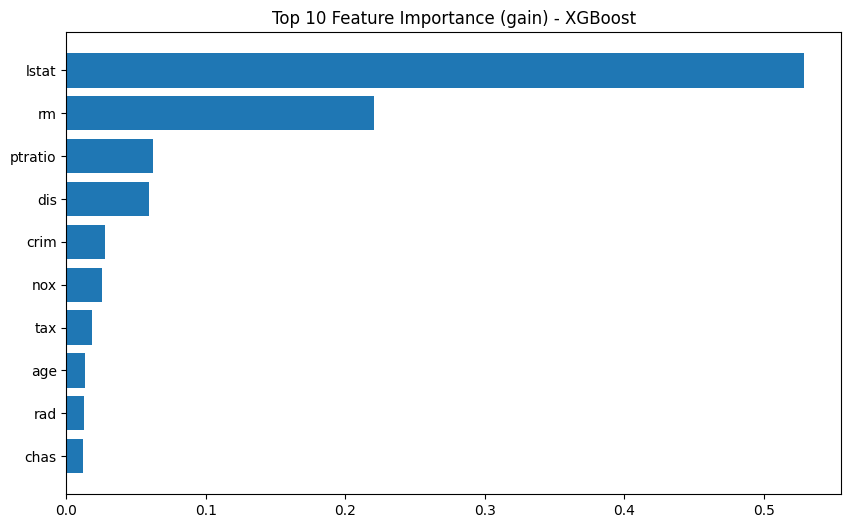

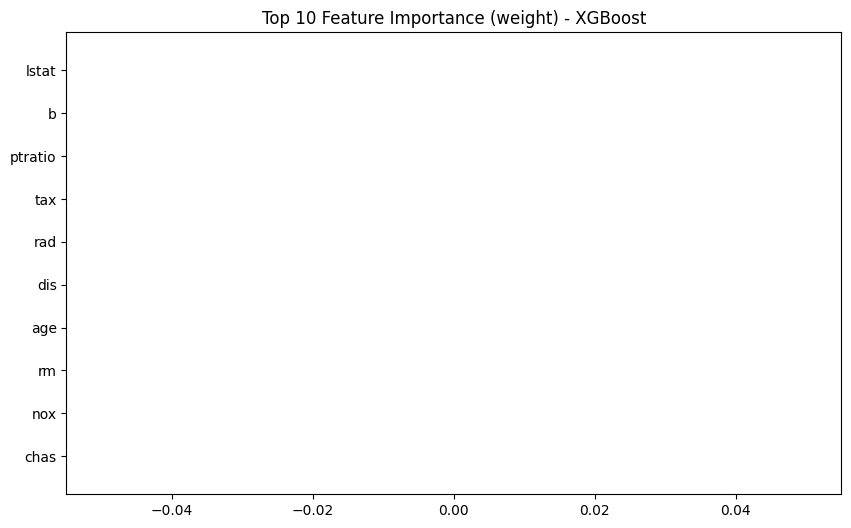

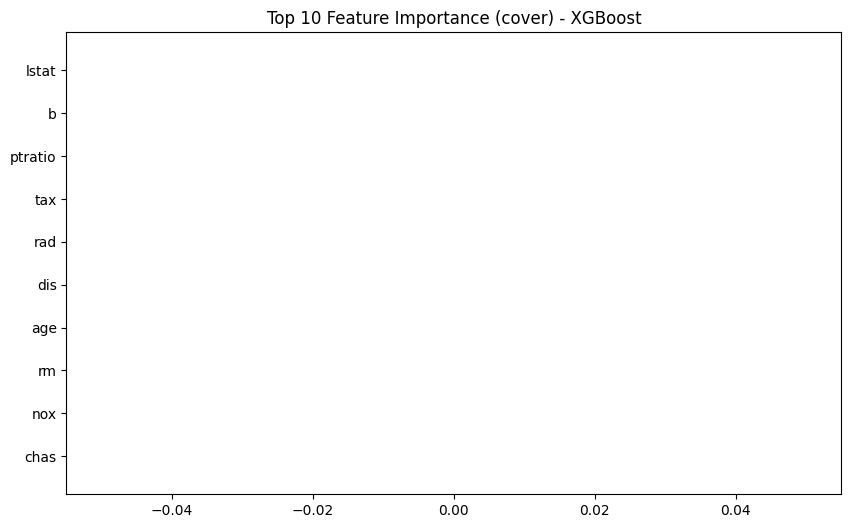

In [23]:
# Ajustar el RandomizedSearchCV para XGBoost
xgb_random_search.fit(X_train, y_train)

# Obtener el mejor modelo entrenado de XGBoost
xgb_best_model = xgb_random_search.best_estimator_.named_steps['classifier']

# Obtener importancia basada en 'gain'
xgb_gain_importance = xgb_best_model.feature_importances_

# También podemos obtener otras importancias (weight y cover)
xgb_booster = xgb_best_model.get_booster()
xgb_weight_importance = xgb_booster.get_score(importance_type='weight')
xgb_cover_importance = xgb_booster.get_score(importance_type='cover')

# Convertir el diccionario de weight y cover a un array para la visualización
xgb_weight_importance_array = np.array([xgb_weight_importance.get(f, 0) for f in processed_columns])
xgb_cover_importance_array = np.array([xgb_cover_importance.get(f, 0) for f in processed_columns])

# Mostrar la importancia de las características basada en 'gain'
plot_feature_importance(xgb_gain_importance, 'XGBoost', processed_columns, importance_type='gain')

# Mostrar importancia basada en 'weight' y 'cover'
plot_feature_importance(xgb_weight_importance_array, 'XGBoost', processed_columns, importance_type='weight')
plot_feature_importance(xgb_cover_importance_array, 'XGBoost', processed_columns, importance_type='cover')

XGBoost Weight Importance: [0 0 0 0 0 0 0 0 0 0 0 0 0]
XGBoost Cover Importance: [0 0 0 0 0 0 0 0 0 0 0 0 0]


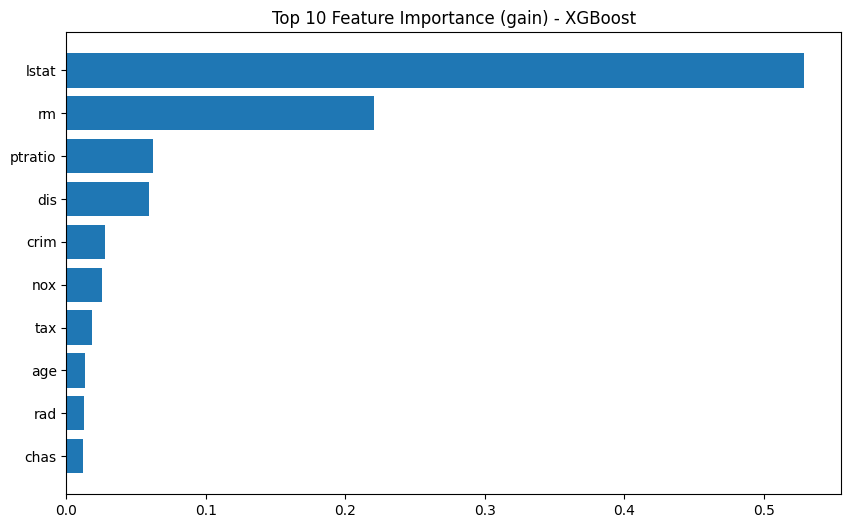

No se encontraron valores de 'weight' significativos para las características.
No se encontraron valores de 'cover' significativos para las características.


In [25]:
# También podemos obtener otras importancias (weight y cover)
xgb_booster = xgb_best_model.get_booster()
xgb_weight_importance = xgb_booster.get_score(importance_type='weight')
xgb_cover_importance = xgb_booster.get_score(importance_type='cover')

# Usar processed_columns en lugar de xgb_booster.feature_names
xgb_weight_importance_array = np.array([xgb_weight_importance.get(f, 0) for f in processed_columns])
xgb_cover_importance_array = np.array([xgb_cover_importance.get(f, 0) for f in processed_columns])

# Verificar si las importancias tienen valores no nulos
print("XGBoost Weight Importance:", xgb_weight_importance_array)
print("XGBoost Cover Importance:", xgb_cover_importance_array)

# Mostrar la importancia de las características basada en 'gain'
plot_feature_importance(xgb_gain_importance, 'XGBoost', processed_columns, importance_type='gain')

# Mostrar importancia basada en 'weight' y 'cover' solo si no son 0
if np.any(xgb_weight_importance_array):
    plot_feature_importance(xgb_weight_importance_array, 'XGBoost', processed_columns, importance_type='weight')
else:
    print("No se encontraron valores de 'weight' significativos para las características.")

if np.any(xgb_cover_importance_array):
    plot_feature_importance(xgb_cover_importance_array, 'XGBoost', processed_columns, importance_type='cover')
else:
    print("No se encontraron valores de 'cover' significativos para las características.")


### Para **LightGBM**:

En LightGBM, podemos usar **Split** (equivalente a "Weight" en XGBoost) y **Gain**.


Se truncaron las últimas líneas 5000 del resultado de transmisión.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 880
[LightGBM] [Info] Number of data points in the train set: 354, number of used features: 13
[LightGBM] [Info] Start training from score 23.015819
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

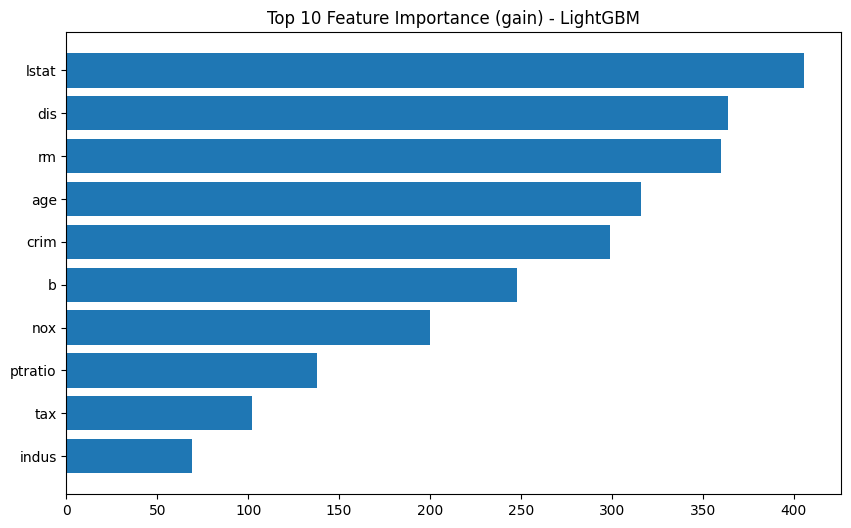

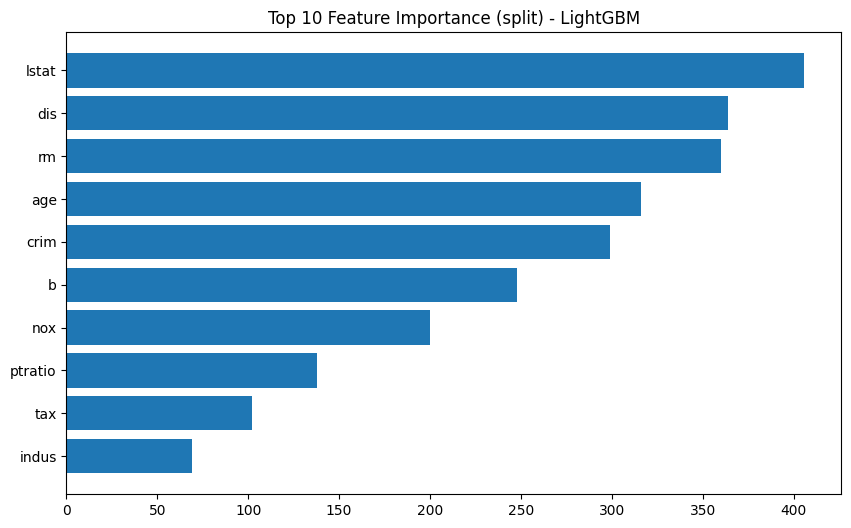

In [27]:
# Asegúrate de ajustar el RandomizedSearchCV antes de intentar acceder a best_estimator_
lgbm_random_search.fit(X_train, y_train)

# Ahora puedes obtener el mejor modelo entrenado de LightGBM
lgbm_best_model = lgbm_random_search.best_estimator_.named_steps['classifier']

# Importancia basada en 'gain' y 'split' (que sería equivalente a weight)
lgbm_gain_importance = lgbm_best_model.feature_importances_  # gain
lgbm_split_importance = lgbm_best_model.booster_.feature_importance(importance_type='split')  # split (weight)

# Mostrar la importancia de las características basada en 'gain'
plot_feature_importance(lgbm_gain_importance, 'LightGBM', processed_columns, importance_type='gain')

# Mostrar la importancia de las características basada en 'split'
plot_feature_importance(lgbm_split_importance, 'LightGBM', processed_columns, importance_type='split')



### Para **CatBoost**:

Para **CatBoost**, además de `get_feature_importance()`, podemos utilizar **Permutation Feature Importance**, que es una técnica que mide cómo afecta la permutación de una característica en particular al rendimiento del modelo.


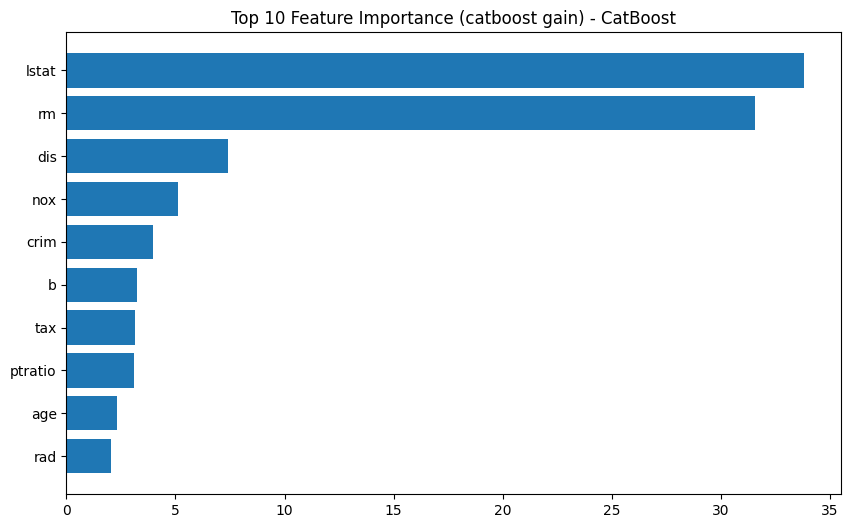

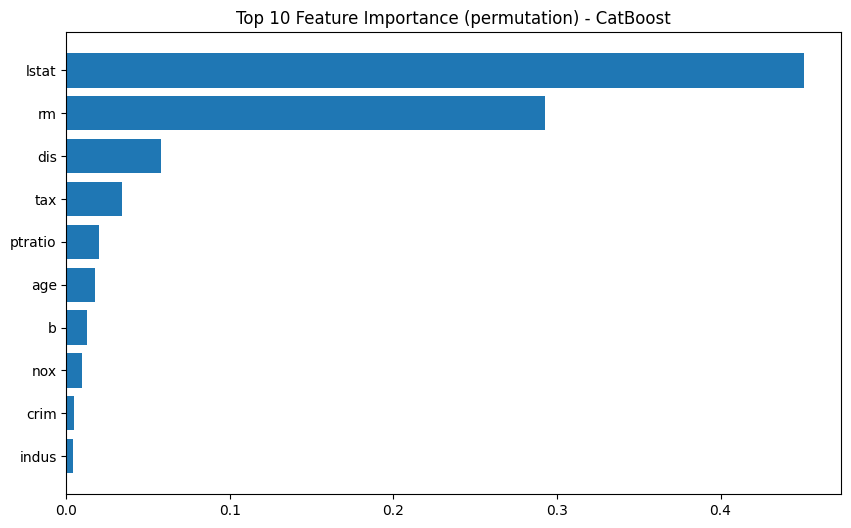

In [29]:
from sklearn.inspection import permutation_importance
# Ajustar el RandomizedSearchCV para CatBoost antes de acceder a best_estimator_
cat_random_search.fit(X_train, y_train)

# Obtener el mejor modelo entrenado de CatBoost
cat_best_model = cat_random_search.best_estimator_

# Obtener importancia usando get_feature_importance() nativo de CatBoost
cat_importance = cat_best_model.get_feature_importance()

# Mostrar la importancia de las características con CatBoost
plot_feature_importance(cat_importance, 'CatBoost', X_train.columns, importance_type='catboost gain')

# Permutation Feature Importance para CatBoost
perm_importance = permutation_importance(cat_best_model, X_test, y_test, n_repeats=10, random_state=42)
perm_importance_mean = perm_importance.importances_mean

# Mostrar la importancia de características usando Permutation Importance
plot_feature_importance(perm_importance_mean, 'CatBoost', X_train.columns, importance_type='permutation')



### Explicación de las métricas de importancia:

1. **Gain**: Cuánto contribuye una característica a reducir la pérdida en promedio en cada rama en la que se utiliza.
2. **Weight (Split)**: Número de veces que se utilizó una característica para dividir un nodo en los árboles.
3. **Cover**: Número de observaciones afectadas por la característica en los nodos divididos.
4. **Permutation Importance**: Evalúa el impacto en el rendimiento del modelo al permutar aleatoriamente los valores de una característica.
